In [47]:
import pandas as pd
from plotnine import *
import plotnine as p9
import re

In [48]:
expe_dt = [336,386,408,481,506,646]
expe_dt = [x/24. for x in expe_dt]
expe_diam = [ 1140 , 1400 , 1590 , 2040 , 2250 , 3040 ]

biodynamo_dt = [14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666, 18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333, 23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5]
biodynamo_diam =  [1240, 1320, 1440, 1560, 1680, 1800, 1920, 2040, 2160, 2280, 2400, 2520, 2640, 2760, 2880, 3000]


In [49]:
# df_tsim_pre = pd.read_csv('../Tisim/use_case_2Ddisk/old_results/result_2d_10_8_3.9_50.txt', sep='\t', engine='python')
# df_tisim = pd.DataFrame({
#     'dt': df_tsim_pre['Time [s]'].iloc[140:] / 86400,  # Convert to days
#     'diam': 2 * df_tsim_pre["Radius of cell population [μm]"].iloc[140:],
#     'Results': 'TiSim'
# })
# df_tisim

df_tsim = pd.read_csv('../Tisim/use_case_2Ddisk/2D disk.csv',sep=',',engine='python')
df_tsim = df_tsim[df_tsim['time (day)'] >= 14]
df_tsim['Results'] = 'TiSim'
df_tsim

,time (day),diameter (um),number,Results
140,14.0,1089.386,11873,TiSim
141,14.1,1103.568,12307,TiSim
142,14.2,1119.310,12748,TiSim
143,14.3,1135.278,13224,TiSim
144,14.4,1151.256,13754,TiSim
...,...,...,...,...
255,25.5,2878.440,139578,TiSim
256,25.6,2893.820,141404,TiSim
257,25.7,2909.200,143238,TiSim
258,25.8,2925.080,145054,TiSim


In [50]:
# with open("../Chaste/use_case_2Ddisk/results/multiple-cells/tissuewidth.dat") as results_file:
#     times = []
#     tissue_widths = []
#     for line in results_file:
#         line = line.replace('\n', '')
#         values = re.split('\t|,', line)
#         if len(values) == 1:
#             continue
        
#         times.append(float(values[0]))
#         tissue_widths.append(float(values[3]))
# df_chaste = pd.DataFrame(data = zip(times,tissue_widths),columns=['dt','diam'])

with open("../Chaste/use_case_2Ddisk/results/monolayer.dat") as results_file:
    times = []
    diameter = []
    cells = []
    for line in results_file:
        line = line.replace('\n', '')
        values = re.split('\t|,', line)
        if len(values) == 1:
            continue
        
        times.append(float(values[0]))
        diameter.append(float(values[1]))
        cells.append(float(values[2]))
df_chaste = pd.DataFrame(data = zip(times,diameter,cells),columns=['dt','diam','cells'])
df_chaste["dt"]=(df_chaste["dt"])/24
df_chaste['Results'] = 'Chaste'
df_chaste


,dt,diam,cells,Results
0,14.000000,1115.40,9124.0,Chaste
1,14.166667,1132.80,9624.0,Chaste
2,14.333333,1159.11,10009.0,Chaste
3,14.500000,1190.47,10508.0,Chaste
4,14.666667,1219.39,11003.0,Chaste
...,...,...,...,...
74,26.333333,3005.99,70805.0,Chaste
75,26.500000,3042.06,72032.0,Chaste
76,26.666667,3059.76,73312.0,Chaste
77,26.833333,3084.83,74521.0,Chaste


In [51]:
# df_pc = pd.read_csv('../Physicell/output/physicell1428.csv' ,sep=',',engine='python')
# df_pc = df_pc.drop(columns=df_pc.columns[0])

df_pc = pd.read_csv('../PhysiCell/results/monolayer/monolayer_t_diam.csv', sep=',', engine='python')
df_pc = df_pc.rename(columns={df_pc.columns[0]: 'dt', df_pc.columns[1]: 'diam'})
# Filter data to start from 14 days
df_pc = df_pc[(df_pc['dt'] >= 14) & (df_pc['dt'] <= 27)]
df_pc['Results'] = 'PhysiCell'
df_pc

,dt,diam,Results
27,14.0,1159.059298,PhysiCell
28,14.5,1247.501410,PhysiCell
29,15.0,1309.014492,PhysiCell
30,15.5,1376.378706,PhysiCell
31,16.0,1462.185936,PhysiCell
32,16.5,1531.357207,PhysiCell
33,17.0,1594.281586,PhysiCell
34,17.5,1677.808345,PhysiCell
35,18.0,1744.060940,PhysiCell
36,18.5,1806.571729,PhysiCell


In [52]:
df_exp = pd.DataFrame(data=zip(expe_dt,expe_diam),columns=['dt','diam'])
df_exp.insert(loc=2, column='Results', value='Experimental')
df_biod = pd.DataFrame(data=zip(biodynamo_dt,biodynamo_diam),columns=['dt','diam'])
df_biod.insert(loc=2, column='Results', value='BioDynaMo')
# df_tisim = pd.DataFrame(data=zip(tisim_dt,tisim_diam),columns=['dt','diam'])
# df_tisim.insert(loc=2, column='Results', value='TiSim')
# df_pc.insert(loc=2, column='Results', value='PhysiCell')
# df_chaste.insert(loc=2,column='Results',value="Chaste")

In [53]:
frames = [df_tisim, df_chaste, df_pc, df_biod, df_exp,]
df_all = pd.concat(frames)

color = {
    'Experimental': 'black', 
    'BioDynaMo': 'red', 
    'TiSim': 'orange',
    'PhysiCell': 'green',
    'Chaste': 'blue'
    }

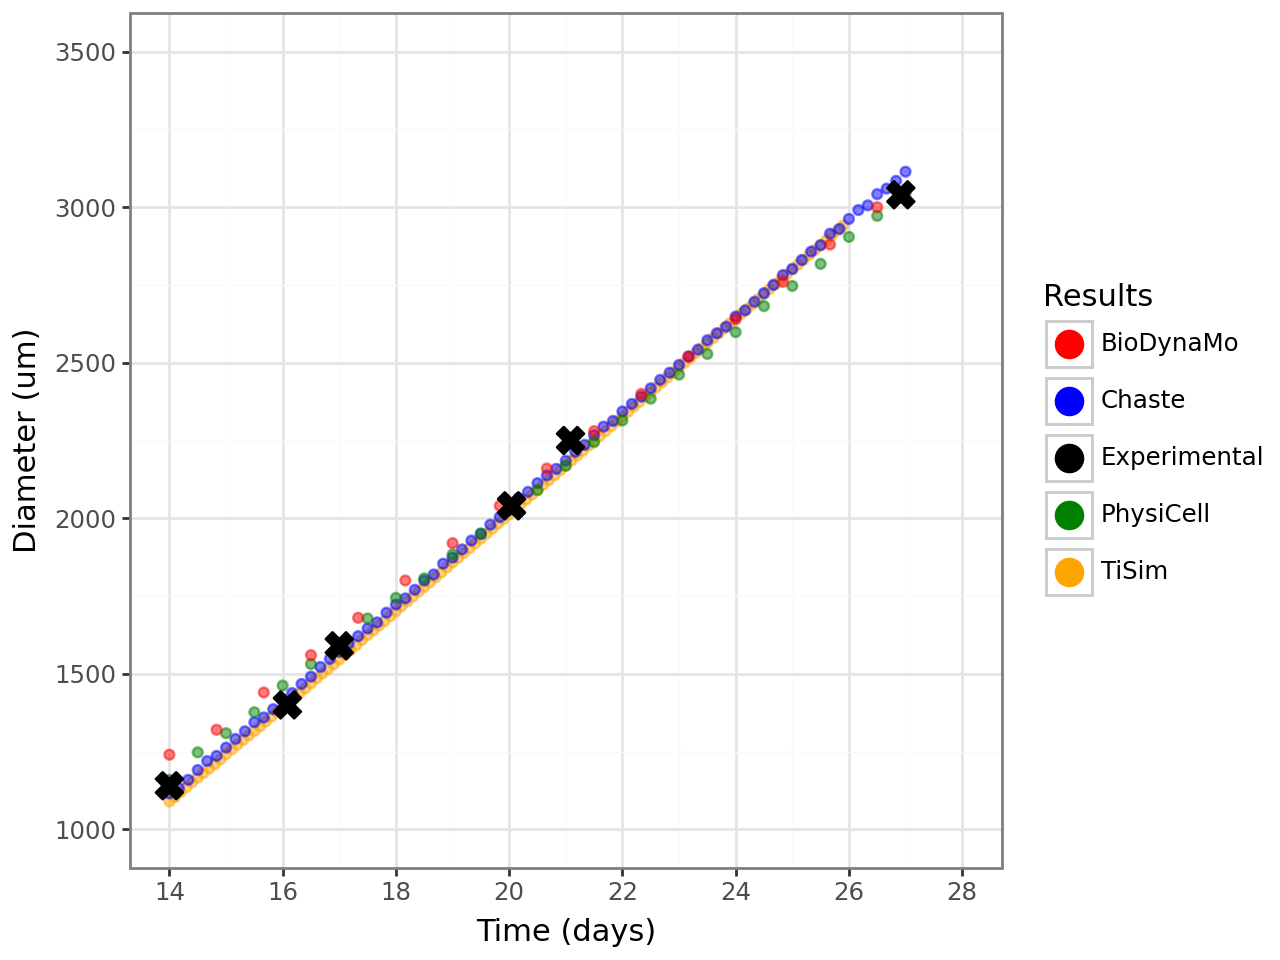

In [54]:
(
    ggplot (df_all) + 
    aes(x='dt',y='diam', colour='Results') + 
    geom_point(alpha = 0.5) +
    geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+
    scale_color_manual(values=color, name="Results")+
    scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+
    scale_y_continuous(name="Diameter (um)", limits={1000, 3500}, breaks = range(0,4000,500))+
    theme_bw()+
    theme(legend_position = "right")+
    guides(colour=guide_legend(override_aes={"shape": 'o'}))
)

In [56]:
monolayer = ggplot (df_all) + \
aes(x='dt',y='diam', colour='Results') + \
geom_point(alpha = 0.5) + \
geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+ \
scale_color_manual(values=color, name="Results")+\
scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+\
scale_y_continuous(name="Diameter (um)", limits={1000, 3500}, breaks = range(0,4000,500))+\
theme_bw()+\
theme(legend_position = "right")+\
guides(colour=guide_legend(override_aes={"shape": 'o'}))

monolayer.save(filename = 'monolayer.png', height=5, width=9, units = 'in', dpi=1000)

/home/amontagud2/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 9 x 5 in image.
/home/amontagud2/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: monolayer.png
